**1. Download and Unzip file**

In [1]:
# Step 1: Direct Download

!wget https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip

# Step 2: Unzip the File

!unzip individual+household+electric+power+consumption.zip


--2026-03-17 02:20:32--  https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘individual+household+electric+power+consumption.zip’

individual+househol     [    <=>             ]  19.68M  25.1MB/s    in 0.8s    

2026-03-17 02:20:33 (25.1 MB/s) - ‘individual+household+electric+power+consumption.zip’ saved [20640916]

Archive:  individual+household+electric+power+consumption.zip
  inflating: household_power_consumption.txt  


**2. Build one Master dataframe, then create model-specific views from it**

In [2]:
# =========================================================
# Step-1: Load the Dataset to Panda
# =========================================================
import pandas as pd
import numpy as np

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)


# =========================================================
# Step-2: Combine Date and Time to create Index (Timestamp)
# =========================================================
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.drop(columns=["Date", "Time"])
df = df.set_index("datetime")


# =========================================================
# Step-3: Convert data type to numeric
# =========================================================
df = df.apply(pd.to_numeric)

# =========================================================
# Step-4: Handle Missing Values
# =========================================================
# Filling Missing Data: Forward_fill/Use previous data
df = df.ffill()


# =========================================================
# Step 5 — Resample to Hourly Data
# =========================================================
df_hourly = df.resample("h").mean()

# =========================================================
# Step 6 — Time features: Linear and Cyclical Encoding
# =========================================================
df_hourly["hour"] = df_hourly.index.hour
df_hourly["day_of_week"] = df_hourly.index.dayofweek
df_hourly["month"] = df_hourly.index.month
df_hourly["weekend"] = (df_hourly.index.dayofweek >= 5).astype(int)
# Cyclical encoding
# Encode Hour of Day: There are 24 hours.
df_hourly["hour_sin"] = np.sin(2*np.pi*df_hourly["hour"]/24)
df_hourly["hour_cos"] = np.cos(2*np.pi*df_hourly["hour"]/24)
# Encode Day of Week: There are 7 days
df_hourly["dow_sin"] = np.sin(2*np.pi*df_hourly["day_of_week"]/7)
df_hourly["dow_cos"] = np.cos(2*np.pi*df_hourly["day_of_week"]/7)
# Encode Month: There are 12 months.
df_hourly["month_sin"] = np.sin(2*np.pi*df_hourly["month"]/12)
df_hourly["month_cos"] = np.cos(2*np.pi*df_hourly["month"]/12)


# =========================================================
# Step 7 —  Lag features
# =========================================================
# Lag features allow models to use past values
target = "Global_active_power"
# previous hour
df_hourly["lag_1"] = df_hourly[target].shift(1)
# same hour yesterday
df_hourly["lag_24"] = df_hourly[target].shift(24)
# same hour last week
df_hourly["lag_168"] = df_hourly[target].shift(168)


# =========================================================
# Step 8 —  Difference features
# =========================================================
# These capture hourly and daily change
df_hourly["diff_1"] = df_hourly[target].diff(1)
df_hourly["diff_24"] = df_hourly[target].diff(24)


# =========================================================
# Step 9 — Rolling features
# =========================================================
# These help to capture recent trends.
df_hourly["rolling_mean_24"] = df_hourly[target].rolling(24).mean()
df_hourly["rolling_std_24"] = df_hourly[target].rolling(24).std()



# =========================================================
# Step 10 — Drop NA created by lag/diff/rolling
# =========================================================
df_hourly = df_hourly.dropna()

# =========================================================
# Step 11 — Final Dataset
# =========================================================
df_hourly.shape


/tmp/ipykernel_44437/2932105848.py:18: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


(34421, 24)

**3. Create Model Specific Views**





In [3]:
# =========================================================
# A. ARIMA / SARIMA View
# =========================================================
# ARIMA/SARIMA should use only the target series.
y_arima = df_hourly["Global_active_power"]

# =========================================================
# B. XGBoost View
# =========================================================
# XGBoost should use engineered tabular features.
xgb_features = [
    "lag_1", "lag_24", "lag_168",
    "diff_1", "diff_24",
    "rolling_mean_24", "rolling_std_24",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "weekend"
]
X_xgb = df_hourly[xgb_features]
y_xgb = df_hourly["Global_active_power"]

# =========================================================
# C. LSTM / Transformer View
# =========================================================
# For deep sequence models, avoid redundant lag features.
# Use raw signals, cyclical features, regime indicators

seq_features = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "weekend"
]

X_seq = df_hourly[seq_features]
y_seq = df_hourly["Global_active_power"]

**4. Data Split, Scaling, & Sequence Builder**

In [4]:
# =========================================================
# One Common Train / Val / Test Split
# =========================================================
# Use one time split for all models
train = df_hourly[:'2009']
val   = df_hourly['2010-01':'2010-06']
test  = df_hourly['2010-07':]

# =========================================================
# ARIMA split...There is no Feature, only Target
# =========================================================
y_train_arima = train["Global_active_power"]
y_val_arima   = val["Global_active_power"]
y_test_arima  = test["Global_active_power"]

# =========================================================
# XGBoost split
# =========================================================
X_train_xgb = train[xgb_features]
X_val_xgb   = val[xgb_features]
X_test_xgb  = test[xgb_features]

y_train_xgb = train["Global_active_power"]
y_val_xgb   = val["Global_active_power"]
y_test_xgb  = test["Global_active_power"]

# =========================================================
# Sequence model split (only for LSTM and Transformer)
# =========================================================
X_train_seq_df = train[seq_features]
X_val_seq_df   = val[seq_features]
X_test_seq_df  = test[seq_features]

y_train_seq_df = train["Global_active_power"]
y_val_seq_df   = val["Global_active_power"]
y_test_seq_df  = test["Global_active_power"]

# =========================================================
# Scaling for XGBoost
# =========================================================
from sklearn.preprocessing import StandardScaler

scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb)
X_val_xgb_scaled   = scaler_xgb.transform(X_val_xgb)
X_test_xgb_scaled  = scaler_xgb.transform(X_test_xgb)

# =========================================================
# Scaling for LSTM / Transformer
# =========================================================
scaler_seq = StandardScaler()
X_train_seq_scaled = scaler_seq.fit_transform(X_train_seq_df)
X_val_seq_scaled   = scaler_seq.transform(X_val_seq_df)
X_test_seq_scaled  = scaler_seq.transform(X_test_seq_df)

# =========================================================
# Sequence Builder (Reusable for LSTM & Transformer)
# =========================================================
import numpy as np

LOOKBACK = 24

def create_sequences(X, y, lookback):
    X = np.asarray(X)
    y = np.asarray(y)

    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_seq_scaled, y_train_seq_df.values, LOOKBACK)
X_val_seq, y_val_seq     = create_sequences(X_val_seq_scaled, y_val_seq_df.values, LOOKBACK)
X_test_seq, y_test_seq   = create_sequences(X_test_seq_scaled, y_test_seq_df.values, LOOKBACK)



**5. A single end-to-end modeling block for all four models: Baseline, XGBoost, Arima/Sarima, LSTM, Transformer**

In [5]:
# =========================================================
# 1) Imports + helper metric function
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf


def evaluate_regression(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} MAE : {mae}")
    print(f"{model_name} RMSE: {rmse}")
    return mae, rmse

In [6]:
# =========================================================
# 2) Baseline Persistence Model
# =========================================================
baseline_pred = y_test_xgb.shift(1).dropna()
baseline_true = y_test_xgb.loc[baseline_pred.index]

baseline_mae, baseline_rmse = evaluate_regression(
    baseline_true,
    baseline_pred,
    model_name="Baseline"
)


Baseline MAE : 0.3581535870883478
Baseline RMSE: 0.562038420463182


In [7]:
# =========================================================
# 3) XGBoost Model: Machine Learning Model
# =========================================================

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse"
)

xgb.fit(
    X_train_xgb_scaled,
    y_train_xgb,
    eval_set=[(X_train_xgb_scaled, y_train_xgb), (X_val_xgb_scaled, y_val_xgb)],
    verbose=False
)

# =========================================================
# predictions
# =========================================================
y_pred_xgb = xgb.predict(X_test_xgb_scaled)

# =========================================================
# evaluation
# =========================================================
xgb_mae, xgb_rmse = evaluate_regression(
    y_test_xgb,
    y_pred_xgb,
    model_name="XGBoost"
)



XGBoost MAE : 0.017137649527447278
XGBoost RMSE: 0.029319586243191146


In [8]:
# =========================================================
# 4) ARIMA /SARIMA Model: Statistical Model
# =========================================================

sarima_model = SARIMAX(
    y_train_arima,
    order=(2,1,2),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

# =========================================================
# forecast on test horizon
# =========================================================

sarima_forecast = sarima_result.forecast(steps=len(y_test_arima))
sarima_forecast = pd.Series(sarima_forecast.values, index=y_test_arima.index)

sarima_mae, sarima_rmse = evaluate_regression(
    y_test_arima,
    sarima_forecast,
    model_name="SARIMA"
)


SARIMA MAE : 1.2415152496544428
SARIMA RMSE: 1.399398738993546


In [9]:
# =========================================================
# 5) LSTM Model: Deep Learning Model
# =========================================================

tf.keras.backend.clear_session()

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train_seq.shape[2])),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-5)
]

history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()

lstm_mae, lstm_rmse = evaluate_regression(
    y_test_seq,
    y_pred_lstm,
    model_name="LSTM"
)

Epoch 1/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.5168 - rmse: 0.7189 - val_loss: 0.2910 - val_rmse: 0.5395 - learning_rate: 0.0010
Epoch 2/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.3494 - rmse: 0.5911 - val_loss: 0.2800 - val_rmse: 0.5292 - learning_rate: 0.0010
Epoch 3/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3290 - rmse: 0.5736 - val_loss: 0.2904 - val_rmse: 0.5389 - learning_rate: 0.0010
Epoch 4/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3168 - rmse: 0.5628 - val_loss: 0.2670 - val_rmse: 0.5168 - learning_rate: 0.0010
Epoch 5/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.3067 - rmse: 0.5538 - val_loss: 0.2692 - val_rmse: 0.5189 - learning_rate: 0.0010
Epoch 6/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2993 - rmse: 0.5471 - val_loss: 0.2646 - val_rmse: 0.5144 - learning_rate: 0.0010
Epoch 7/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2907 - rmse: 0.5391 - val_loss: 0.2600 - val_rmse: 0.5099 - learnin

In [10]:
# =========================================================
# 6) Transformer: Deep Learning Model
# =========================================================

def build_transformer(input_shape):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Dense(64)(inputs)

    attention = tf.keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )(x, x)

    x = tf.keras.layers.Add()([x, attention])
    x = tf.keras.layers.LayerNormalization()(x)

    ff = tf.keras.layers.Dense(128, activation="relu")(x)
    ff = tf.keras.layers.Dropout(0.1)(ff)
    ff = tf.keras.layers.Dense(64)(ff)

    x = tf.keras.layers.Add()([x, ff])
    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model


tf.keras.backend.clear_session()

transformer = build_transformer(
    input_shape=(LOOKBACK, X_train_seq.shape[2])
)

history_trans = transformer.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

y_pred_trans = transformer.predict(X_test_seq, verbose=0).flatten()

trans_mae, trans_rmse = evaluate_regression(
    y_test_seq,
    y_pred_trans,
    model_name="Transformer"
)


Epoch 1/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.7406 - rmse: 0.8606 - val_loss: 0.5864 - val_rmse: 0.7658 - learning_rate: 0.0010
Epoch 2/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.6022 - rmse: 0.7760 - val_loss: 0.4582 - val_rmse: 0.6769 - learning_rate: 0.0010
Epoch 3/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.5468 - rmse: 0.7394 - val_loss: 0.4671 - val_rmse: 0.6835 - learning_rate: 0.0010
Epoch 4/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.4678 - rmse: 0.6839 - val_loss: 0.4269 - val_rmse: 0.6534 - learning_rate: 5.0000e-04
Epoch 5/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.4321 - rmse: 0.6573 - val_loss: 0.4187 - val_rmse: 0.6470 - learning_rate: 5.0000e-04
Transformer MAE : 0.4829895794391632
Transformer RMSE: 0.6489259190268618


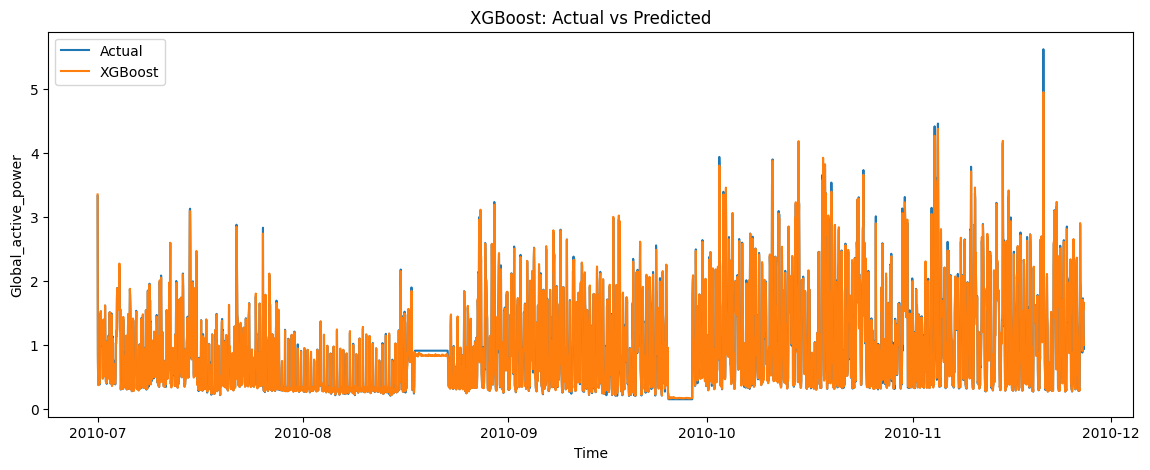

In [11]:
# =========================================================
# 7) Actual vs Predicted Plots: for XGBoost
# =========================================================

plt.figure(figsize=(14,5))
plt.plot(test.index, y_test_xgb.values, label="Actual")
plt.plot(test.index, y_pred_xgb, label="XGBoost")
plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()




In [12]:
# =========================================================
# Model Comparation Table
# =========================================================

results = pd.DataFrame({
    "Model": ["Baseline", "XGBoost", "SARIMA", "LSTM", "Transformer"],
    "MAE": [baseline_mae, xgb_mae, sarima_mae, lstm_mae, trans_mae],
    "RMSE": [baseline_rmse, xgb_rmse, sarima_rmse, lstm_rmse, trans_rmse]
})

print(results)



         Model       MAE      RMSE
0     Baseline  0.358154  0.562038
1      XGBoost  0.017138  0.029320
2       SARIMA  1.241515  1.399399
3         LSTM  0.310442  0.447331
4  Transformer  0.482990  0.648926


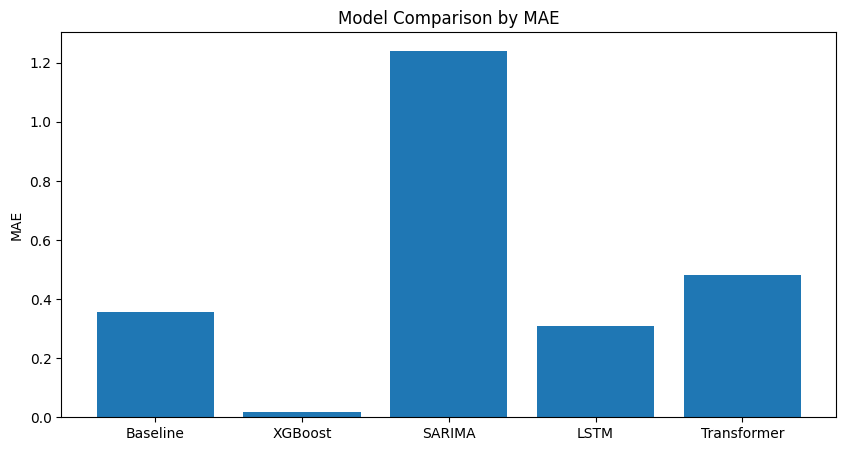

In [13]:
# =========================================================
# Model Comparation Chart
# =========================================================

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison by MAE")
plt.ylabel("MAE")
plt.show()

**6.  Walk-forward forecasting**

In [14]:
# =========================================================
# Step 1 — Walk-forward function
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

def walk_forward_xgb(data, feature_cols, target_col, initial_train_size=24*365, step_size=24*7):
    """
    initial_train_size: hours in initial training window
    step_size: forecast block size (e.g. 1 week = 24*7)
    """
    results = []
    predictions = []

    for start in range(initial_train_size, len(data) - step_size, step_size):
        train = data.iloc[:start].copy()
        test = data.iloc[start:start+step_size].copy()

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            eval_metric="rmse"
        )

        model.fit(X_train_scaled, y_train, verbose=False)
        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            "start_time": test.index.min(),
            "end_time": test.index.max(),
            "MAE": mae,
            "RMSE": rmse
        })

        pred_df = pd.DataFrame({
            "actual": y_test.values,
            "predicted": y_pred
        }, index=test.index)

        predictions.append(pred_df)

    results_df = pd.DataFrame(results)
    preds_df = pd.concat(predictions)

    return results_df, preds_df

In [15]:
# =========================================================
# Step 2 — Run walk-forward evaluation
# =========================================================

feature_cols = xgb_features
target_col = "Global_active_power"

wf_results_xgb, wf_preds_xgb = walk_forward_xgb(  # Rolling forcasting
    df_hourly,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=24*365*2,   # first 2 years
    step_size=24*7                  # predict 1 week at a time
)

print(wf_results_xgb.head())
print("Average MAE :", wf_results_xgb["MAE"].mean())
print("Average RMSE:", wf_results_xgb["RMSE"].mean())



           start_time            end_time       MAE      RMSE
0 2008-12-22 17:00:00 2008-12-29 16:00:00  0.022424  0.031352
1 2008-12-29 17:00:00 2009-01-05 16:00:00  0.021330  0.030772
2 2009-01-05 17:00:00 2009-01-12 16:00:00  0.022812  0.037109
3 2009-01-12 17:00:00 2009-01-19 16:00:00  0.030383  0.061058
4 2009-01-19 17:00:00 2009-01-26 16:00:00  0.024678  0.040941
Average MAE : 0.0186671961038685
Average RMSE: 0.02960711119897474


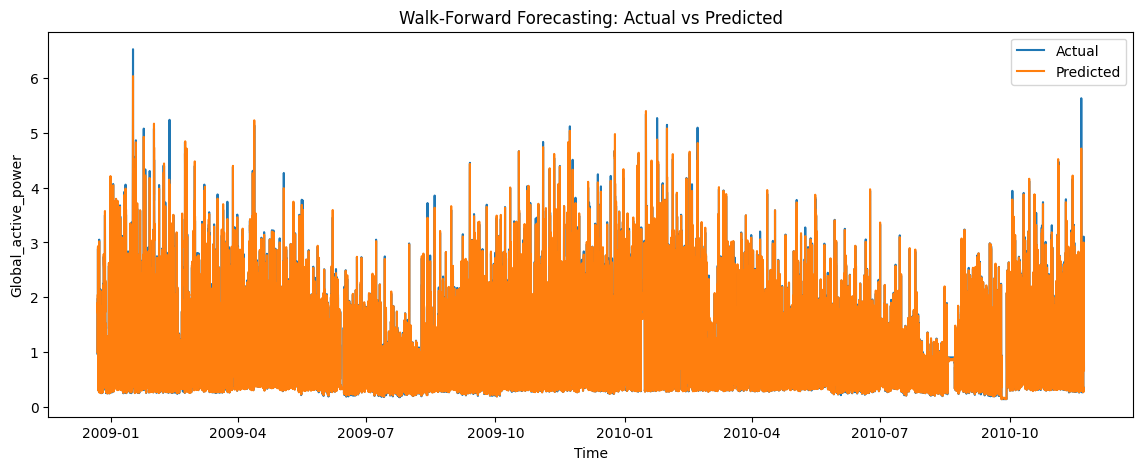

In [16]:
# Step 4 — Plot actual vs predicted for walk-forward results
plt.figure(figsize=(14,5))
plt.plot(wf_preds_xgb.index, wf_preds_xgb["actual"], label="Actual")
plt.plot(wf_preds_xgb.index, wf_preds_xgb["predicted"], label="Predicted")
plt.title("Walk-Forward Forecasting: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

 **7. Multi-step forecasting (24-hour ahead)**

In [17]:
# =========================================================
# Step 1 — Create 24-step sequences
# =========================================================
LOOKBACK = 24
HORIZON = 24
# LOOKBACK = 24
# HORIZON = 24

def create_multistep_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    X = np.asarray(X)
    y = np.asarray(y)

    for i in range(lookback, len(X) - horizon + 1):
        Xs.append(X[i-lookback:i])
        ys.append(y[i:i+horizon])

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

In [18]:
# =========================================================
# Step 2 — Build sequence datasets
# =========================================================
from sklearn.preprocessing import StandardScaler

seq_train = train[seq_features]
seq_val   = val[seq_features]
seq_test  = test[seq_features]

y_train_ms = train["Global_active_power"]
y_val_ms   = val["Global_active_power"]
y_test_ms  = test["Global_active_power"]

scaler_ms = StandardScaler()
X_train_ms_scaled = scaler_ms.fit_transform(seq_train)
X_val_ms_scaled   = scaler_ms.transform(seq_val)
X_test_ms_scaled  = scaler_ms.transform(seq_test)

X_train_ms, y_train_ms_seq = create_multistep_sequences(X_train_ms_scaled, y_train_ms.values, LOOKBACK, HORIZON)
X_val_ms, y_val_ms_seq     = create_multistep_sequences(X_val_ms_scaled, y_val_ms.values, LOOKBACK, HORIZON)
X_test_ms, y_test_ms_seq   = create_multistep_sequences(X_test_ms_scaled, y_test_ms.values, LOOKBACK, HORIZON)

print(X_train_ms.shape, y_train_ms_seq.shape)

(26456, 24, 14) (26456, 24)


In [19]:
# =========================================================
# Step 3 — LSTM for 24-hour forecasting
# =========================================================
import tensorflow as tf

tf.keras.backend.clear_session()

multi_lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train_ms.shape[2])),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(HORIZON)
])

multi_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

history_multi_lstm = multi_lstm.fit(
    X_train_ms,
    y_train_ms_seq,
    validation_data=(X_val_ms, y_val_ms_seq),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.7267 - rmse: 0.8525 - val_loss: 0.4448 - val_rmse: 0.6670
Epoch 2/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.5294 - rmse: 0.7276 - val_loss: 0.4407 - val_rmse: 0.6639
Epoch 3/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.4929 - rmse: 0.7021 - val_loss: 0.4431 - val_rmse: 0.6657
Epoch 4/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.4686 - rmse: 0.6846 - val_loss: 0.4525 - val_rmse: 0.6727
Epoch 5/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.4505 - rmse: 0.6712 - val_loss: 0.4534 - val_rmse: 0.6734
Epoch 6/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.4329 - rmse: 0.6579 - val_loss: 0.4803 - val_rmse: 0.6931
Epoch 7/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.4191 - rmse: 0.6473 - val_loss: 0.4605 - val_rmse: 0.6786
Epoch 8/30
414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.4064 - rmse: 0.6375 - val_loss: 0.4719 - val_rmse: 0.6869
Epoch 9/30
414/414 ━━━━━━━━━━━━━

In [20]:
# =========================================================
# Step 4 — Evaluate multi-step forecast
# =========================================================

y_pred_multi_lstm = multi_lstm.predict(X_test_ms, verbose=0)

mae_multi = mean_absolute_error(y_test_ms_seq.flatten(), y_pred_multi_lstm.flatten())
rmse_multi = np.sqrt(mean_squared_error(y_test_ms_seq.flatten(), y_pred_multi_lstm.flatten()))

print("24-step LSTM MAE :", mae_multi)
print("24-step LSTM RMSE:", rmse_multi)


24-step LSTM MAE : 0.45998281240463257
24-step LSTM RMSE: 0.6611166744995399


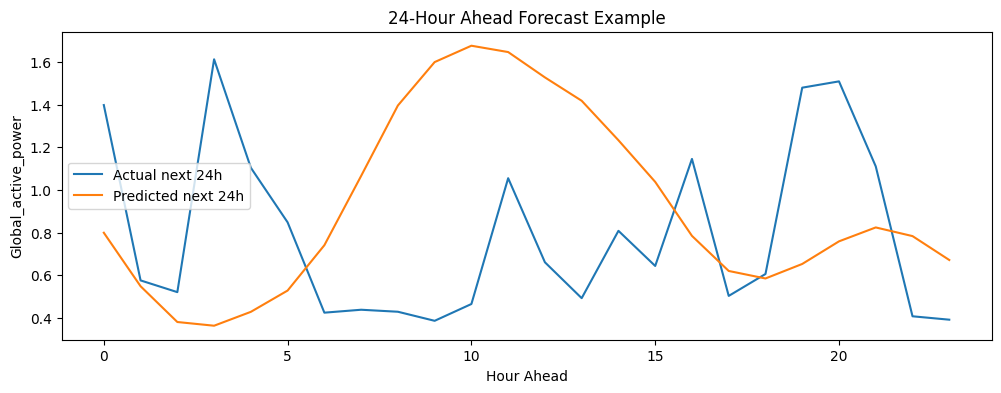

In [21]:
# =========================================================
# Step 5 — Plot one 24-hour forecast horizon
# =========================================================

sample_idx = 0

plt.figure(figsize=(12,4))
plt.plot(y_test_ms_seq[sample_idx], label="Actual next 24h")
plt.plot(y_pred_multi_lstm[sample_idx], label="Predicted next 24h")
plt.title("24-Hour Ahead Forecast Example")
plt.xlabel("Hour Ahead")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

**8. Explainability: Transformer Attention**

In [22]:
# =========================================================
# Step 1 — Build Transformer with attention output
# =========================================================

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)
        self.last_attention_scores = None

    def call(self, inputs, training=False):
        attn_output, attn_scores = self.att(
            inputs, inputs,
            return_attention_scores=True
        )
        self.last_attention_scores = attn_scores
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [23]:
# =========================================================
# Step 2 — Build attention-aware Transformer
# =========================================================

def build_transformer_with_attention(input_shape, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Dense(embed_dim)(inputs)

    transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
    x = transformer_block(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )

    return model, transformer_block

In [24]:
# =========================================================
# Step 3 — Train it
# =========================================================
tf.keras.backend.clear_session()

transformer_attn, transformer_block = build_transformer_with_attention(
    input_shape=(LOOKBACK, X_train_seq.shape[2])
)

history_attn = transformer_attn.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.7356 - rmse: 0.8576 - val_loss: 0.5787 - val_rmse: 0.7607
Epoch 2/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5892 - rmse: 0.7676 - val_loss: 0.4422 - val_rmse: 0.6650
Epoch 3/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.4992 - rmse: 0.7065 - val_loss: 0.4346 - val_rmse: 0.6592
Epoch 4/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.4533 - rmse: 0.6733 - val_loss: 0.3803 - val_rmse: 0.6167
Epoch 5/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.4177 - rmse: 0.6463 - val_loss: 0.3647 - val_rmse: 0.6039
Epoch 6/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.3928 - rmse: 0.6267 - val_loss: 0.3547 - val_rmse: 0.5956
Epoch 7/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.3793 - rmse: 0.6159 - val_loss: 0.3417 - val_rmse: 0.5845
Epoch 8/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.3671 - rmse: 0.6059 - val_loss: 0.3559 - val_rmse: 0.5965
Epoch 9/20
414/414 ━━━━━━━━━━━━

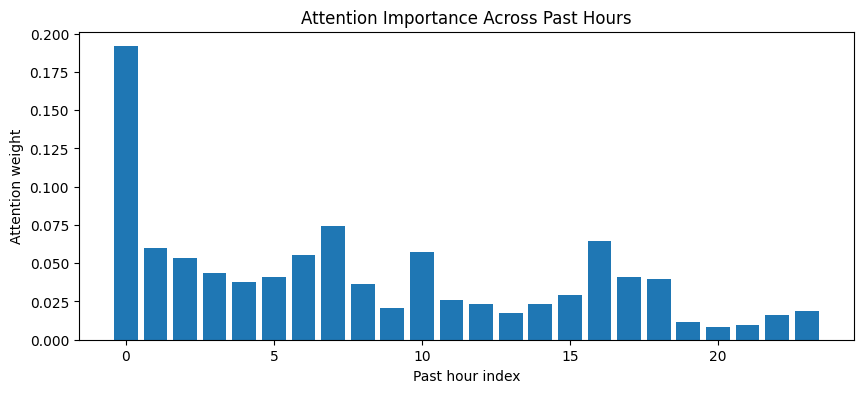

In [25]:
# =========================================================
# Step 4 — Visualize which past hours mattered
# =========================================================
sample = X_test_seq[:1]
_ = transformer_attn(sample, training=False)

attention_scores = transformer_block.last_attention_scores.numpy()
# shape: (batch, heads, query_len, key_len)

avg_attention = attention_scores.mean(axis=1)[0]   # average over heads
importance = avg_attention.mean(axis=0)            # average over query positions

plt.figure(figsize=(10,4))
plt.bar(range(len(importance)), importance)
plt.title("Attention Importance Across Past Hours")
plt.xlabel("Past hour index")
plt.ylabel("Attention weight")
plt.show()


**9. Anomaly Detection**

Number of anomalies: 167


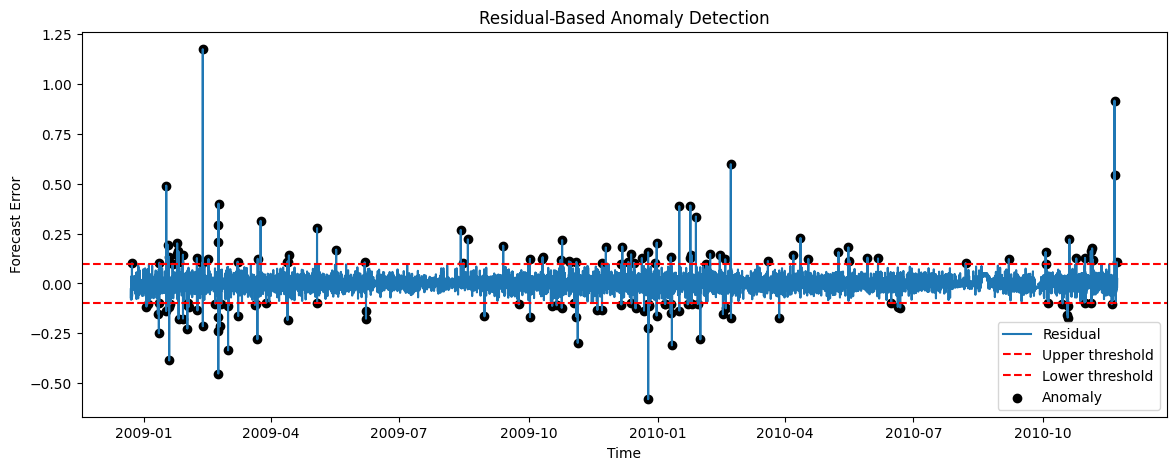

In [26]:
# =========================================================
# Step 1 — Compute residuals from XGBoost walk-forward predictions
# =========================================================
wf_preds_xgb["residual"] = wf_preds_xgb["actual"] - wf_preds_xgb["predicted"]

# =========================================================
# Step 2 — Create anomaly threshold
# =========================================================

# Simple rule: flag residuals above 3 standard deviations.
resid_mean = wf_preds_xgb["residual"].mean()
resid_std = wf_preds_xgb["residual"].std()

upper = resid_mean + 3 * resid_std
lower = resid_mean - 3 * resid_std

wf_preds_xgb["anomaly"] = (
    (wf_preds_xgb["residual"] > upper) |
    (wf_preds_xgb["residual"] < lower)
).astype(int)

print("Number of anomalies:", wf_preds_xgb["anomaly"].sum())

# =========================================================
# Step 3 — Plot anomalies on residuals
# =========================================================
plt.figure(figsize=(14,5))
plt.plot(wf_preds_xgb.index, wf_preds_xgb["residual"], label="Residual")
plt.axhline(upper, color="red", linestyle="--", label="Upper threshold")
plt.axhline(lower, color="red", linestyle="--", label="Lower threshold")

anoms = wf_preds_xgb[wf_preds_xgb["anomaly"] == 1]
plt.scatter(anoms.index, anoms["residual"], color="black", label="Anomaly")

plt.title("Residual-Based Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Forecast Error")
plt.legend()
plt.show()


**12. Trend Analysis**

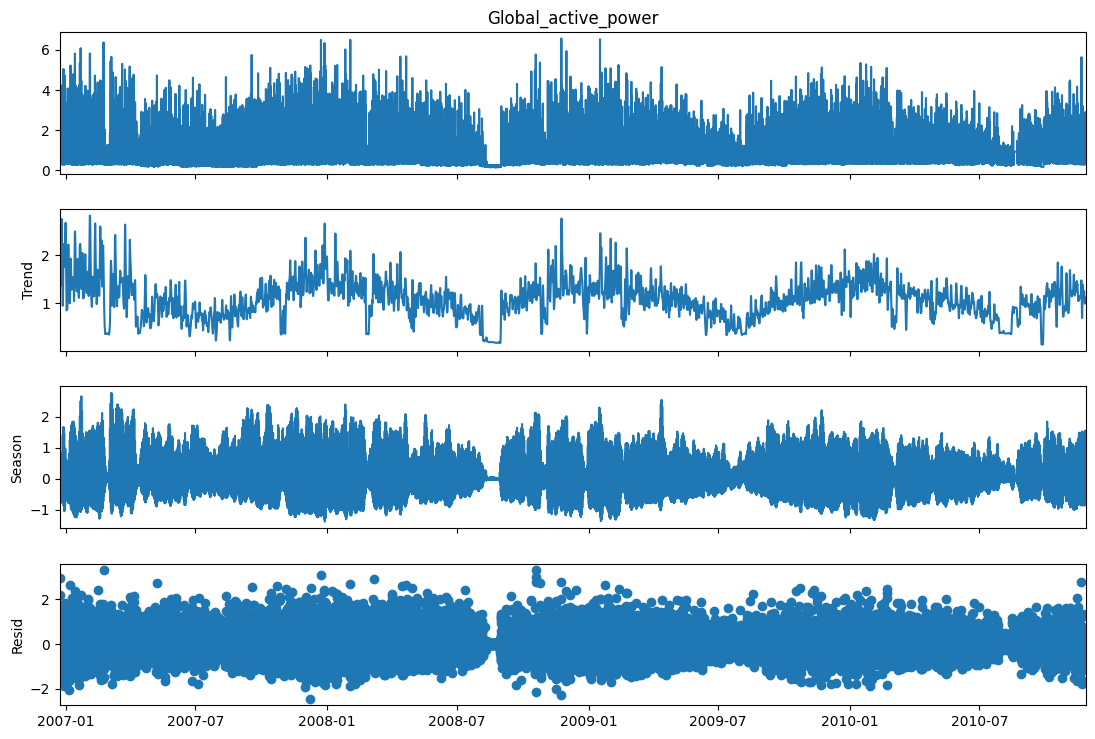

In [27]:
# =========================================================
# Step 1 — Moving average trend
# =========================================================
df_hourly["trend_24h"] = df_hourly["Global_active_power"].rolling(24).mean()
df_hourly["trend_7d"] = df_hourly["Global_active_power"].rolling(24*7).mean()

# =========================================================
# Step 2 — Seasonal decomposition
# =========================================================
from statsmodels.tsa.seasonal import STL

stl = STL(df_hourly["Global_active_power"], period=24)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

